In [1]:
from QLBM import QLBMV2, collision, InitializeQC
from QLBM_4 import QLBM4, collision4, InitializeQC4
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y, N_POINTS_Z = 32, 32, 32
# Simulation parameters

NUMBER_DISCRETE_VELOCITIES = 27  # D2Q9 lattice configuration

TIMESTEPS = 20000

In [3]:
Qq = 27

Nx = 31
Ny = 31
Nz = 31
dx = 1
dy = 1
dz = 1
dt = dx
c = dx/dt
cs = np.sqrt(c**2/3)
f_eq = np.zeros((Qq, Nx+1, Ny+1, Ny+1))
f = np.zeros((Qq, Nx+1, Ny+1, Ny+1))
Tf_eq = np.zeros((Qq, Nx+1, Ny+1, Ny+1))
Tf = np.zeros((Qq, Nx+1, Ny+1, Ny+1))
f_star = np.zeros((Qq, Nx+1, Ny+1, Ny+1))
Lx = dx * float(Nx)
Ly = dy * float(Ny)
Lz = dz * float(Nz)

rho_beta = 1e-5
T_l = 2.0
T_r = 1.0
T_star = (T_l+T_r)/2.0
Pr = 0.71
Ra = 1000
Re = np.sqrt(Ra/Pr)

nu = np.sqrt((rho_beta*(T_l-T_r)*Pr*Lx**3)/Ra)
alpha = nu/Pr

nu_star = 1/6*dt
alpha_star = 1/6*dt
tau_f = 1.0

rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, Ny+1, 3))
T = np.zeros((Nx+1, Ny+1, Ny+1))
e = np.array([
    [0,  1, -1,  0,  0,   0,  0,  1, -1,  1, -1,  0,  0,  1, -1,  1, -1,  0,  0,  1, -1,  1, -1,  1, -1, -1,  1],
    [0,  0,  0,  1, -1,   0,  0,  1, -1,  0,  0,  1, -1, -1,  1,  0,  0,  1, -1,  1, -1,  1, -1, -1,  1,  1, -1],
    [0,  0,  0,  0,  0,   1, -1,  0,  0,  1, -1,  1, -1,  0,  0, -1,  1, -1,  1,  1, -1, -1,  1,  1, -1,  1, -1]
]).T
w = np.array([
    8/27,                   
    2/27, 2/27, 2/27, 2/27, 2/27, 2/27,  
    1/54, 1/54, 1/54, 1/54, 1/54, 1/54, 1/54, 1/54, 1/54, 1/54, 1/54, 1/54,  
    1/216, 1/216, 1/216, 1/216, 1/216, 1/216, 1/216, 1/216  
])

u_n = u[:, :, :, 0].copy()
v_n = u[:, :, :, 1].copy() 
w_n = u[:, :, :, 2].copy()
T_n = T[:, :, :].copy()
u_t = np.zeros((Nx+3, Ny+3, Ny+3))
v_t = np.zeros((Nx+3, Ny+3, Ny+3))
w_t = np.zeros((Nx+3, Ny+3, Ny+3))
T_t = np.zeros((Nx+3, Ny+3, Ny+3))
u_d = np.zeros((Nx+1, Ny+1, Ny+1))
v_d = np.zeros((Nx+1, Ny+1, Ny+1))
w_d = np.zeros((Nx+1, Ny+1, Ny+1))
T_d = np.zeros((Nx+1, Ny+1, Ny+1))

T_t_x = np.zeros((Nx+1, Ny+1, Ny+1))
T_t_y = np.zeros((Nx+1, Ny+1, Ny+1))
T_t_z = np.zeros((Nx+1, Ny+1, Ny+1))
u_t_x = np.zeros((Nx+1, Ny+1, Ny+1))
v_t_x = np.zeros((Nx+1, Ny+1, Ny+1))
u_t_z = np.zeros((Nx+1, Ny+1, Ny+1))
u_t_y = np.zeros((Nx+1, Ny+1, Ny+1))
v_t_y = np.zeros((Nx+1, Ny+1, Ny+1))
v_t_z = np.zeros((Nx+1, Ny+1, Ny+1))
w_t_x = np.zeros((Nx+1, Ny+1, Ny+1))
w_t_y = np.zeros((Nx+1, Ny+1, Ny+1))
w_t_z = np.zeros((Nx+1, Ny+1, Ny+1))

A = 3/4 - 9/2*nu/dt
B = 1/2 - alpha/dt/cs**2
q_error=[]
c_error=[]
qc_error=[]

print(nu,alpha,nu-nu_star,alpha-alpha_star)

0.014543593091117477 0.020483933931151378 -0.1521230735755492 -0.14618273273551527


In [4]:
##Initial
x0 = np.linspace(0,Lx,Nx+1)
y0 = np.linspace(0,Ly,Ny+1)
z0 = np.linspace(0,Lz,Nz+1)
print(x0,y0,z0)
X0,Y0,Z0 = np.meshgrid(x0,y0,z0)
rho[:, :, :] = rho_0
T[:,:,:] = T_star
T[0,:,:] = T_l
T[-1,:,:] = T_r


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31.] [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31.] [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31.]


In [5]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator4 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [ ]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y, N_POINTS_Z))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y, N_POINTS_Z))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y, N_POINTS_Z))
Psi_qlbm3 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y, N_POINTS_Z))
Psi_qlbm4 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y, N_POINTS_Z))
Psi_qlbm[0, :, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :, :] = u[:,:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :, :] = u[:,:,:,1].copy()#Psi_init
Psi_qlbm3[0, :, :, :] = u[:,:,:,2].copy()#Psi_init
Psi_qlbm4[0, :, :, :] = T.copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, N_POINTS_Z, 3))
u_LBM[:, :, :, 0] = Psi_qlbm1[0, :, :,:]  # Set the x-component of the velocity
u_LBM[:, :, :, 1] = Psi_qlbm2[0, :, :,:]  # Set the y-component of the velocity
u_LBM[:, :, :, 2] = Psi_qlbm3[0, :, :,:]  # Set the z-component of the velocity

# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    u_t[1:-1,1:-1,1:-1] = u[:,:,:,0].copy()
    v_t[1:-1,1:-1,1:-1] = u[:,:,:,1].copy()
    w_t[1:-1,1:-1,1:-1] = u[:,:,:,2].copy()
    T_t[1:-1,1:-1,1:-1] = T[:,:,:].copy()

    u_t[0,1:-1,1:-1] = -u[1,:,:,0].copy()
    u_t[-1,1:-1,1:-1] = -u[-2,:,:,0].copy()
    u_t[1:-1,0,1:-1] = -u[:,1,:,0].copy()
    u_t[1:-1,-1,1:-1] = -u[:,-2,:,0].copy()
    u_t[1:-1,1:-1,0] = -u[:,:,1,0].copy()
    u_t[1:-1,1:-1,-1] = -u[:,:,-2,0].copy()

    v_t[0,1:-1,1:-1] = -u[1,:,:,1].copy()
    v_t[-1,1:-1,1:-1] = -u[-2,:,:,1].copy()
    v_t[1:-1,0,1:-1] = -u[:,1,:,1].copy()
    v_t[1:-1,-1,1:-1] = -u[:,-2,:,1].copy()
    v_t[1:-1,1:-1,0] = -u[:,:,1,1].copy()
    v_t[1:-1,1:-1,-1] = -u[:,:,-2,1].copy()

    w_t[0,1:-1,1:-1] = -u[1,:,:,2].copy()
    w_t[-1,1:-1,1:-1] = -u[-2,:,:,2].copy()
    w_t[1:-1,0,1:-1] = -u[:,1,:,2].copy()
    w_t[1:-1,-1,1:-1] = -u[:,-2,:,2].copy()
    w_t[1:-1,1:-1,0] = -u[:,:,1,2].copy()
    w_t[1:-1,1:-1,-1] = -u[:,:,-2,2].copy()

    T_t[0,1:-1,1:-1] = 4.0-T[1,:,:].copy()
    T_t[-1,1:-1,1:-1] = 2.0-T[-2,:,:].copy()
    T_t[1:-1,0,1:-1] = T[:,1,:].copy()
    T_t[1:-1,-1,1:-1] = T[:,-2,:].copy()
    T_t[1:-1,1:-1,0] = T[:,:,1].copy()
    T_t[1:-1,1:-1,-1] = T[:,:,-2].copy()


    u_t_y = (u_t[1:-1, 2:, 1:-1] - u_t[1:-1, :-2, 1:-1])/(2.0*dy)
    u_t_x = (u_t[2:, 1:-1, 1:-1] - u_t[:-2, 1:-1, 1:-1])/(2.0*dx)
    u_t_z = (u_t[1:-1, 1:-1, 2:] - u_t[1:-1, 1:-1, :-2])/(2.0*dz)
   
    v_t_y = (v_t[1:-1, 2:, 1:-1] - v_t[1:-1, :-2, 1:-1])/(2.0*dy)
    v_t_x = (v_t[2:, 1:-1, 1:-1] - v_t[:-2, 1:-1, 1:-1])/(2.0*dx)
    v_t_z = (v_t[1:-1, 1:-1, 2:] - v_t[1:-1, 1:-1, :-2])/(2.0*dz)

    w_t_y = (w_t[1:-1, 2:, 1:-1] - w_t[1:-1, :-2, 1:-1])/(2.0*dy)
    w_t_x = (w_t[2:, 1:-1, 1:-1] - w_t[:-2, 1:-1, 1:-1])/(2.0*dx)
    w_t_z = (w_t[1:-1, 1:-1, 2:] - w_t[1:-1, 1:-1, :-2])/(2.0*dz)

    T_t_y = (T_t[1:-1, 2:, 1:-1] - T_t[1:-1, :-2, 1:-1])/(2.0*dy)
    T_t_x = (T_t[2:, 1:-1, 1:-1] - T_t[:-2, 1:-1, 1:-1])/(2.0*dx)
    T_t_z = (T_t[1:-1, 1:-1, 2:] - T_t[1:-1, 1:-1, :-2])/(2.0*dz)

    temp = u[:, :, :, 0] * u[:, :, :, 0] + u[:, :, :, 1] * u[:, :, :, 1]+ u[:, :, :, 2] * u[:, :, :, 2]
    for Q in range(27):
        f_eq[Q,:, :, :] = w[Q]*rho*(1.0 + 3.0 * (e[Q, 0] * u[:, :, :, 0] + e[Q, 1] * u[:, :, :, 1] + e[Q, 2] * u[:, :, :, 2]) + 4.5 * (e[Q, 0] * u[:, :, :, 0] + e[Q, 1] * u[:, :, :, 1] + e[Q, 2] * u[:, :, :, 2]) ** 2 - 1.5 * temp +\
                                  A*dt*(u_t_x + u_t_x)*e[Q,0]*e[Q,0] + A*dt*(v_t_x + u_t_y)*e[Q,0]*e[Q,1] + A*dt*(w_t_x + u_t_z)*e[Q,0]*e[Q,2]+\
                                  A*dt*(u_t_y + v_t_x)*e[Q,0]*e[Q,1] + A*dt*(v_t_y + v_t_y)*e[Q,1]*e[Q,1] + A*dt*(w_t_y + v_t_z)*e[Q,2]*e[Q,1]+\
                                  A*dt*(u_t_z + w_t_x)*e[Q,0]*e[Q,2] + A*dt*(v_t_z + w_t_y)*e[Q,1]*e[Q,2] + A*dt*(w_t_z + w_t_z)*e[Q,2]*e[Q,2]
                                  ) + 3.0*w[Q]*rho_beta*(T - T_star)*e[Q,1]*dt
        Tf_eq[Q,:, :, :] = w[Q]*T*(1.0 + 3.0 * (e[Q, 0] * u[:, :, :, 0] + e[Q, 1] * u[:, :, :, 1] + e[Q, 2] * u[:, :, :, 2]) + 4.5 * (e[Q, 0] * u[:, :, :, 0] + e[Q, 1] * u[:, :, :, 1] + e[Q, 2] * u[:, :, :, 2]) ** 2 - 1.5 * temp+\
                                   B*dt*(T_t_y*e[Q,1] + T_t_x*e[Q,0] + T_t_z*e[Q,2])/T)
        f[Q, :, :, :] = f[Q, :, :, :] - (f[Q, :, :, :] - f_eq[Q, :, :, :]) / tau_f
        Tf[Q, :, :, :] =Tf[Q, :, :, :] - (Tf[Q, :, :, :] - Tf_eq[Q, :, :, :]) / tau_f
    

    for vvv in range(27):
        f[vvv, :, :, :] = np.roll(
            np.roll(
                np.roll(f[vvv, :, :, :], e[vvv, 0], axis=0),
                e[vvv, 1], axis=1
            ),
            e[vvv, 2], axis=2
        )
        Tf[vvv, :, :, :] = np.roll(
            np.roll(
                np.roll(Tf[vvv, :, :, :], e[vvv, 0], axis=0),
                e[vvv, 1], axis=1
            ),
            e[vvv, 2], axis=2
        )

    rho = np.sum(f, axis=0)
    T = np.sum(Tf, axis=0)
    u[:, :, :, 0] = np.sum(f * e[:,0].reshape(27,1,1,1), axis=0) / rho
    u[:, :, :, 1] = np.sum(f * e[:,1].reshape(27,1,1,1), axis=0) / rho
    u[:, :, :, 2] = np.sum(f * e[:,2].reshape(27,1,1,1), axis=0) / rho

    T[:, 0,:] = 4/3*T[:, 1,:] - 1/3*T[:, 2,:]
    T[:, Ny,:] = 4/3*T[:, Ny-1,:] - 1/3*T[:, Ny-2,:]
    T[:,:, 0] = 4/3*T[:,:, 1] - 1/3*T[:,:, 2]
    T[:,:, Ny] = 4/3*T[:,:, Ny-1] - 1/3*T[:,:, Ny-2]
    T[0, :,:] = T_l
    T[Ny, :,:] = T_r

    u[:, 0,:, 0] = u[0, :,:, 0] = u[Nx, :,:, 0] = u[:, Ny,:, 0]= u[:, :,0, 0]= u[:, :, Ny, 0] = 0.0
    u[:, 0,:, 1] = u[0, :,:, 1] = u[Nx, :,:, 1] = u[:, Ny,:, 1]= u[:, :,0, 1]= u[:, :, Ny, 1] = 0.0
    u[:, 0,:, 2] = u[0, :,:, 2] = u[Nx, :,:, 2] = u[:, Ny,:, 2]= u[:, :,0, 2]= u[:, :, Ny, 2] = 0.0

    rho[:,:, 0] = (3.0*rho[:,:,1]-3.0*rho[:,:,2]+ 1.0*rho[:,:,3])
    rho[:,:, Nz] = (3.0*rho[:,:,Nz-1]-3.0*rho[:,:,Nz-2]+ 1.0*rho[:,:,Nz-3])
    rho[0, :,:] = (3.0*rho[1, :,:]- 3.0*rho[2, :,:]+ 1.0*rho[3, :,:])
    rho[Nx, :,:] = (3.0*rho[Nx-1,:,:]- 3.0*rho[Nx-2,:,:]+ 1.0*rho[Nx-3,:,:])
    rho[:, 0,:] = (3.0*rho[:,1,:]- 3.0*rho[:,2,:]+ 1.0*rho[:,3,:])
    rho[:, Ny,:] = (3.0*rho[:,Ny-1,:]- 3.0*rho[:,Ny-2,:]+ 1.0*rho[:,3,:])
    
    error = np.sum(np.sqrt((T_n[1:-1,1:-1,1:-1]-T[1:-1,1:-1,1:-1])**2+(u_n[1:-1,1:-1,1:-1]-u[1:-1,1:-1,1:-1, 0])**2+(v_n[1:-1,1:-1,1:-1]-u[1:-1,1:-1,1:-1, 1])**2+(w_n[1:-1,1:-1,1:-1]-u[1:-1,1:-1,1:-1, 2])**2))/np.sum(np.sqrt(T[1:-1,1:-1,1:-1]**2+u[1:-1,1:-1,1:-1, 0]**2+u[1:-1,1:-1,1:-1, 1]**2+u[1:-1,1:-1,1:-1, 2]**2))
    u_n = u[:, :, :, 0].copy() 
    v_n = u[:, :, :, 1].copy()
    w_n = u[:, :, :, 2].copy()
    T_n = T[:, :, :].copy()
    
    # Create and run the quantum circuit for LBM, rho
    qc = QLBMV2(density_field=Psi_qlbm[t, :, :, :], velocity_field=u_LBM, T_field=Psi_qlbm4[t,:,:,:], number_velocities=NUMBER_DISCRETE_VELOCITIES)
    
    # Compile and run the quantum circuit
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()
    
    # Extract and process the statevector
    statevector = np.array(result.get_statevector())
    real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y * N_POINTS_Z*27])
    reshaped_real_part = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y, N_POINTS_Z,27),order='F')
    
    # Normalize and update Psi_qlbm
    norm_factor = np.linalg.norm(Psi_qlbm[t, :, :, :].flatten())
    fq = reshaped_real_part * norm_factor
    Psi_qlbm[t + 1, :, :, :] = np.sum(fq, axis=3)
    Psi_qlbm1[t + 1, :, :, :] = np.sum(fq * e[:,0].reshape(1,1,1,27), axis=3) / Psi_qlbm[t + 1, :, :, :]
    Psi_qlbm2[t + 1, :, :, :] = np.sum(fq * e[:,1].reshape(1,1,1,27), axis=3) / Psi_qlbm[t + 1, :, :, :]
    Psi_qlbm3[t + 1, :, :, :] = np.sum(fq * e[:,2].reshape(1,1,1,27), axis=3) / Psi_qlbm[t + 1, :, :, :]
    Psi_qlbm[t + 1,:,:, 0] = 3.0*Psi_qlbm[t + 1,:,:,1]-3.0*Psi_qlbm[t + 1,:,:,2] + 1.0*Psi_qlbm[t + 1,:,:,3]
    Psi_qlbm[t + 1,:,:, Nz] = 3.0*Psi_qlbm[t + 1,:,:,Nz-1]-3.0*Psi_qlbm[t + 1,:,:,Nz-2] + 1.0*Psi_qlbm[t + 1,:,:,Nz-3]
    Psi_qlbm[t + 1,0, :,:] = 3.0*Psi_qlbm[t + 1,1, :,:] - 3.0*Psi_qlbm[t + 1,2, :,:] + 1.0*Psi_qlbm[t + 1,3, :,:]
    Psi_qlbm[t + 1,Nx, :,:] = 3.0*Psi_qlbm[t + 1,Nx-1,:,:] - 3.0*Psi_qlbm[t + 1,Nx-2,:,:] + 1.0*Psi_qlbm[t + 1,Nx-3,:,:]
    Psi_qlbm[t + 1,:, 0,:] = 3.0*Psi_qlbm[t + 1,:,1,:] - 3.0*Psi_qlbm[t + 1,:,2,:] + 1.0*Psi_qlbm[t + 1,:,3,:]
    Psi_qlbm[t + 1,:, Ny,:] = 3.0*Psi_qlbm[t + 1,:,Ny-1,:] - 3.0*Psi_qlbm[t + 1,:,Ny-2,:] + 1.0*Psi_qlbm[t + 1,:,Ny-3,:] 
    
    Psi_qlbm1[t + 1,:, 0,:] = Psi_qlbm1[t + 1,0, :,:] = Psi_qlbm1[t + 1,Nx, :,:] = Psi_qlbm1[t + 1,:, Ny,:]= Psi_qlbm1[t + 1,:, :,0]=Psi_qlbm1[t + 1,:, :, Nz] = 0.0
    Psi_qlbm2[t + 1,:, 0,:] = Psi_qlbm2[t + 1,0, :,:] = Psi_qlbm2[t + 1,Nx, :,:] = Psi_qlbm2[t + 1,:, Ny,:]= Psi_qlbm2[t + 1,:, :,0]= Psi_qlbm2[t + 1,:, :, Nz] = 0.0
    Psi_qlbm3[t + 1,:, 0,:] = Psi_qlbm3[t + 1,0, :,:] = Psi_qlbm3[t + 1,Nx, :,:] = Psi_qlbm3[t + 1,:, Ny,:]= Psi_qlbm3[t + 1,:, :,0]= Psi_qlbm3[t + 1,:, :, Nz] = 0.0

    qc4 = QLBM4(density_field=Psi_qlbm4[t,:,:,:], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit4 = transpile(qc4, simulator4)
    result4 = simulator4.run(compiled_circuit4).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector4 = np.array(result4.get_statevector())
    real_part_statevector4 = np.real(statevector4[:N_POINTS_X * N_POINTS_Y * N_POINTS_Z])
    real_part_statevector_reshaped4 = np.reshape(real_part_statevector4, (N_POINTS_X, N_POINTS_Y, N_POINTS_Z), order='F')
    norm_factor4 = np.linalg.norm(Psi_qlbm4[t,:,:,:].flatten()) * 4 * np.sqrt(2)
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm4[t + 1, :, :, :] = real_part_statevector_reshaped4 * norm_factor4

    Psi_qlbm4[t + 1,:, 0,:] = 4/3*Psi_qlbm4[t + 1,:, 1,:] - 1/3*Psi_qlbm4[t + 1,:, 2,:]
    Psi_qlbm4[t + 1,:, Ny,:] = 4/3*Psi_qlbm4[t + 1,:, Ny-1,:] - 1/3*Psi_qlbm4[t + 1,:, Ny-2,:]
    Psi_qlbm4[t + 1,:,:, 0] = 4/3*Psi_qlbm4[t + 1,:,:, 1] - 1/3*Psi_qlbm4[t + 1,:,:, 2]
    Psi_qlbm4[t + 1,:,:, Ny] = 4/3*Psi_qlbm4[t + 1,:,:, Ny-1] - 1/3*Psi_qlbm4[t + 1,:,:, Ny-2]
    Psi_qlbm4[t + 1,0, :,:] = T_l
    Psi_qlbm4[t + 1,Ny, :,:] = T_r#""""""

    Psi_qlbm0 = Psi_qlbm[t + 1, :, :, :].copy()

    u_LBM[:,:, :,0] = Psi_qlbm1[t + 1, :, :, :]
    u_LBM[:,:, :,1] = Psi_qlbm2[t + 1, :, :, :]
    u_LBM[:,:, :,2] = Psi_qlbm3[t + 1, :, :, :]
    error1 = np.sum(np.sqrt((Psi_qlbm1[t + 1, 1:-1,1:-1,1:-1]-Psi_qlbm1[t, 1:-1,1:-1,1:-1])**2+(Psi_qlbm2[t + 1, 1:-1,1:-1,1:-1]-Psi_qlbm2[t, 1:-1,1:-1,1:-1])**2+(Psi_qlbm3[t + 1, 1:-1,1:-1,1:-1]-Psi_qlbm3[t, 1:-1,1:-1,1:-1])**2+(Psi_qlbm4[t + 1, 1:-1,1:-1,1:-1]-Psi_qlbm4[t, 1:-1,1:-1,1:-1])**2))/np.sum(np.sqrt(Psi_qlbm1[t + 1, 1:-1,1:-1,1:-1]**2+Psi_qlbm2[t + 1, 1:-1,1:-1,1:-1]**2+Psi_qlbm3[t + 1, 1:-1,1:-1,1:-1]**2+Psi_qlbm4[t + 1, 1:-1,1:-1,1:-1]**2))
    error2 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :, :]-v_n)**2+(Psi_qlbm3[t + 1, :, :, :]-w_n)**2+(Psi_qlbm4[t + 1, :, :, :]-T_n)**2))/np.sum(np.sqrt(u_n**2+v_n**2+w_n**2+T_n**2))
    print(t+1,error,error1,error2)

    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)

    if error1 < 1e-6 and error < 1e-6:
        break

1 1.0 0.002813764381874618 0.00021884914480040915


In [7]:
print(t+1,error,error1,error2)

15009 0.0025566735941341414 6.5477968943458e-07 0.0056403362728824884


In [ ]:
np.savetxt("Ra=1000_32\QLBM_u_"+str(t)+".csv",Psi_qlbm1[t,:,:,:].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\QLBM_v_"+str(t)+".csv",Psi_qlbm2[t,:,:,:].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\QLBM_w_"+str(t)+".csv",Psi_qlbm3[t,:,:,:].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\QLBM_T_"+str(t)+".csv",Psi_qlbm4[t,:,:,:].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\QLBM_rho_"+str(t)+".csv",Psi_qlbm[t,:,:,:].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\CLBM_u_"+str(t)+".csv",u[:,:,:,0].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\CLBM_v_"+str(t)+".csv",u[:,:,:,1].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\CLBM_w_"+str(t)+".csv",u[:,:,:,2].reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\CLBM_T_"+str(t)+".csv",T.reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")
np.savetxt("Ra=1000_32\CLBM_rho_"+str(t)+".csv",rho.reshape(N_POINTS_X*N_POINTS_Y*N_POINTS_Z,1),delimiter=",")

In [ ]:
np.savetxt("Ra=1000_32\QLBM_error.csv",q_error,delimiter=",")
np.savetxt("Ra=1000_32\CLBM_error.csv",c_error,delimiter=",")
np.savetxt("Ra=1000_32\QLBM_CLBM_error.csv",qc_error,delimiter=",")

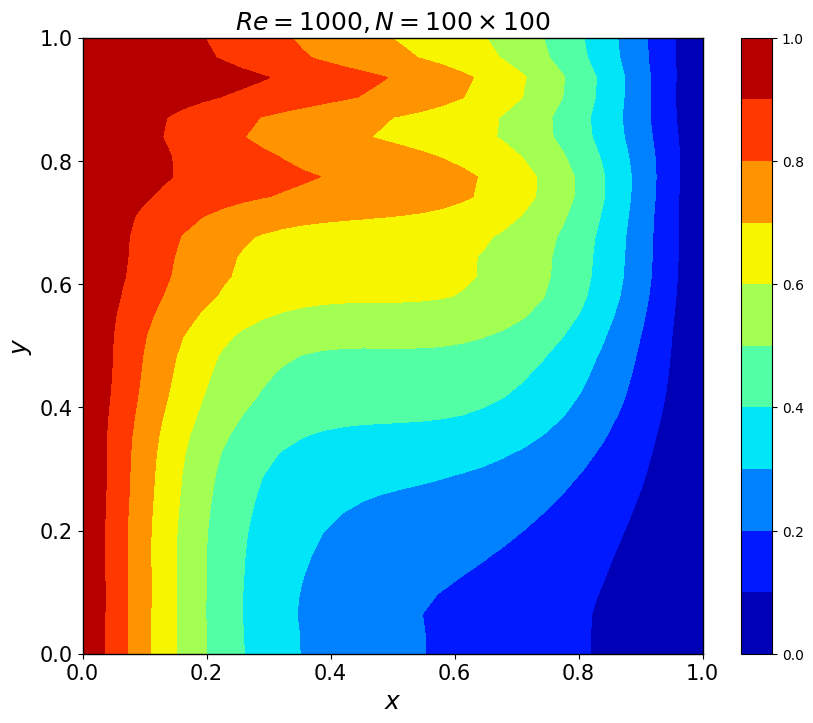

In [ ]:
x = np.linspace(0,1,Nx+1)[:,None]
y = np.linspace(0,1,Ny+1)[:,None]
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(10, 8))
plt.contourf(X,Y,(T[:,:,int(Nx/2)].T+T[:,:,int(Nx/2)-1].T)/2-1,11,cmap = 'jet')
plt.colorbar()
plt.tick_params(labelsize=15)
plt.xlim(0.0,1.0)
plt.xlabel('$x$', size = 18)
plt.ylabel('$y$', size = 18)
plt.title(r"$Ra=1000,N = 32 \times 32$", size = 18)
plt.ylim(0.0,1.0)
fig1=plt.gcf()
ax=plt.gca();#获得坐标轴的句柄
ax.spines['bottom'].set_linewidth(1)###设置底部坐标轴的粗细
ax.spines['left'].set_linewidth(1)####设置左边坐标轴的粗细
ax.spines['right'].set_linewidth(1)###设置右边坐标轴的粗细
ax.spines['top'].set_linewidth(1)
#plt.savefig('plot_T.jpg', format='jpg', dpi=100)
plt.show()

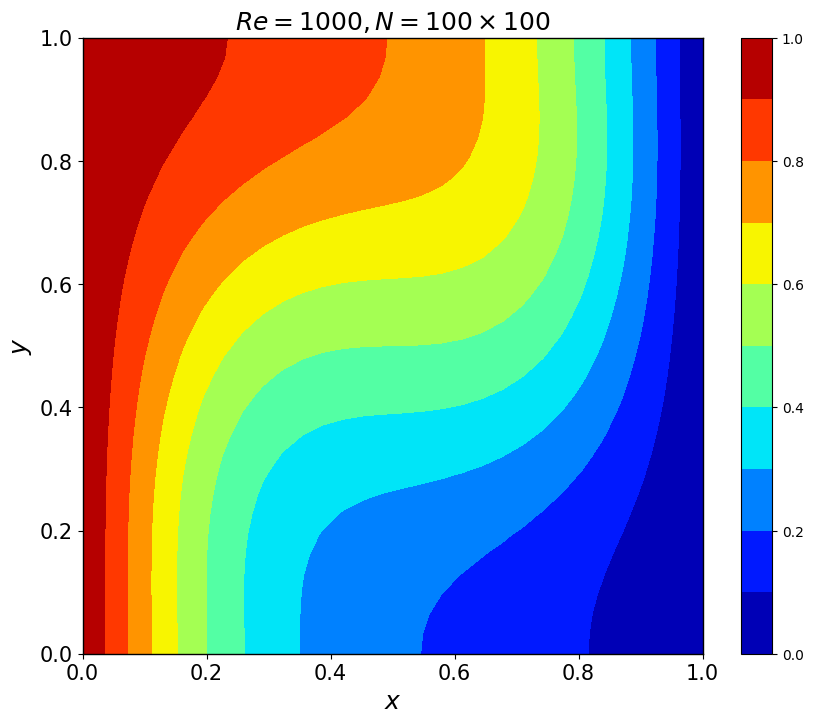

In [ ]:
x = np.linspace(0,1,Nx+1)[:,None]
y = np.linspace(0,1,Ny+1)[:,None]
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(10, 8))
plt.contourf(X,Y,(Psi_qlbm4[t,:,:,int(Nx/2)].T+Psi_qlbm4[t,:,:,int(Nx/2)-1].T)/2-1,11,cmap = 'jet')
plt.colorbar()
plt.tick_params(labelsize=15)
plt.xlim(0.0,1.0)
plt.xlabel('$x$', size = 18)
plt.ylabel('$y$', size = 18)
plt.title(r"$Ra=1000,N = 32 \times 32$", size = 18)
plt.ylim(0.0,1.0)
fig1=plt.gcf()
ax=plt.gca();#获得坐标轴的句柄
ax.spines['bottom'].set_linewidth(1)###设置底部坐标轴的粗细
ax.spines['left'].set_linewidth(1)####设置左边坐标轴的粗细
ax.spines['right'].set_linewidth(1)###设置右边坐标轴的粗细
ax.spines['top'].set_linewidth(1)
#plt.savefig('plot_T.jpg', format='jpg', dpi=100)
plt.show()